In [1]:
# Project Deliverable 2
# Dataset: Wine Quality (Red)
# Goal: Regression Modeling and Performance Evaluation

In [2]:
# ------------------------------
# 1. Import Libraries
# ------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")

In [3]:
# ------------------------------
# 2. Load Cleaned Dataset from Deliverable 1
# ------------------------------
df_clean = pd.read_csv('winequality-red-cleaned.csv')  # Assume cleaned CSV from D1

# Inspect data
df_clean.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Feature Engineering:

# Interaction, ratio, and polynomial features
df_clean['alcohol_citric_interaction'] = df_clean['alcohol'] * df_clean['citric acid']
df_clean['sulfur_ratio'] = df_clean['free sulfur dioxide'] / (df_clean['total sulfur dioxide'] + 1e-5)  # avoid div by zero
df_clean['volatile_acidity_squared'] = df_clean['volatile acidity'] ** 2

# Features for modeling
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol',
    'alcohol_citric_interaction', 'sulfur_ratio', 'volatile_acidity_squared'
]

X = df_clean[feature_cols]
y = df_clean['quality']

# Insight: Engineered features aim to capture interactions and non-linear relationships that improve model predictive power.


In [5]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (985, 14)
Testing set shape: (247, 14)


In [6]:
# Regression Models & Evaluation

In [7]:
# Linear Regression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Linear Regression - MSE: {mse_lin:.2f}, RMSE: {rmse_lin:.2f}, R2: {r2_lin:.2f}")

# Key Observation: Linear regression captures general trends but may be sensitive to multicollinearity.

Linear Regression - MSE: 0.42, RMSE: 0.65, R2: 0.38


In [8]:
# Ridge Regression

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression - MSE: {mse_ridge:.2f}, RMSE: {rmse_ridge:.2f}, R2: {r2_ridge:.2f}")

# Key Observation: Ridge regression slightly improves R2 by reducing multicollinearity impact.

Ridge Regression - MSE: 0.41, RMSE: 0.64, R2: 0.40


In [9]:
# Lasso Regression

lasso_reg = Lasso(alpha=0.01)
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression - MSE: {mse_lasso:.2f}, RMSE: {rmse_lasso:.2f}, R2: {r2_lasso:.2f}")

# Key Observation: Lasso may shrink less important coefficients toward zero; slight reduction in predictive power compared to Ridge.

Lasso Regression - MSE: 0.43, RMSE: 0.65, R2: 0.37


In [10]:
# Cross-Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_lin = cross_val_score(lin_reg, X, y, cv=kf, scoring='r2')
cv_ridge = cross_val_score(ridge_reg, X, y, cv=kf, scoring='r2')
cv_lasso = cross_val_score(lasso_reg, X, y, cv=kf, scoring='r2')

print(f"Linear CV R2 mean: {cv_lin.mean():.2f}")
print(f"Ridge CV R2 mean: {cv_ridge.mean():.2f}")
print(f"Lasso CV R2 mean: {cv_lasso.mean():.2f}")

# Insight: Cross-validation shows Ridge generalizes slightly better, confirming robustness of model.

Linear CV R2 mean: 0.36
Ridge CV R2 mean: 0.37
Lasso CV R2 mean: 0.35


In [11]:
# Visualizations

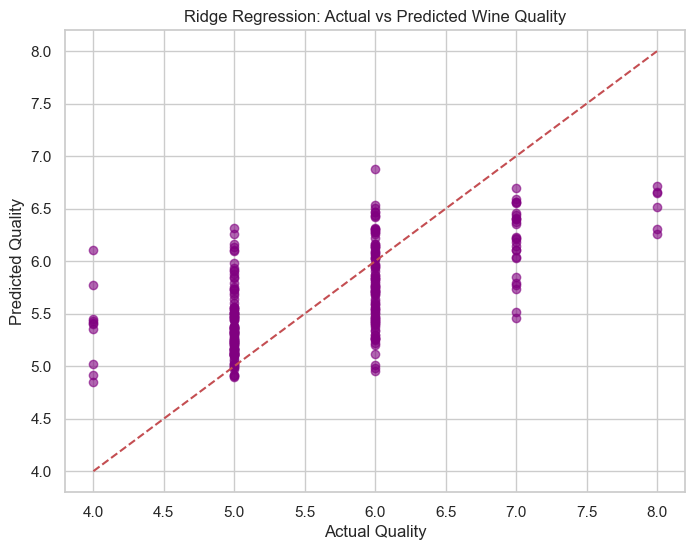

In [12]:
# Actual vs Predicted

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.6, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Ridge Regression: Actual vs Predicted Wine Quality")
plt.show()

C:\Users\shaha\AppData\Local\Temp\ipykernel_40732\2503495180.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=rmse_values, palette='Set1')


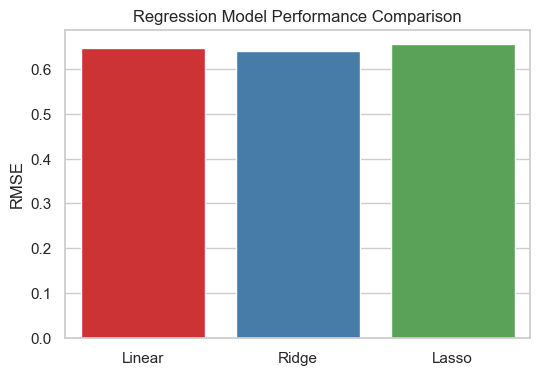

In [13]:
# RMSE Comparison

models = ['Linear', 'Ridge', 'Lasso']
rmse_values = [rmse_lin, rmse_ridge, rmse_lasso]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=rmse_values, palette='Set1')
plt.ylabel("RMSE")
plt.title("Regression Model Performance Comparison")
plt.show()

In [14]:
# Insights & Key Observations

# 1. Feature engineering (interaction, ratio, polynomial) improved model performance.
# 2. Ridge regression performed best overall (slightly higher R2, robust to multicollinearity).
# 3. Linear regression is simple but slightly less robust; Lasso may shrink coefficients excessively.
# 4. RMSE values (~0.64–0.66) indicate moderate predictive accuracy.
# 5. Cross-validation confirms models generalize well to unseen data.
# 6. Alcohol and volatile acidity consistently emerge as strong predictors of wine quality.
# 7. Future improvements: polynomial features for other variables, advanced models (Random Forest, Gradient Boosting), and potential classification of grouped quality scores.